## Report: Benchmarking Self-Made Linear Regression Algorithms
The following shows the functionality of the gradient descent algorithm in linear_regression.py and the QR factorization method in qr_decomp.py. Both are designed to solve a system of linear equations and make a "best fit" line for multidimensional data. While there already exists QR decomposition and linear regression classes in the Sklearn library, knowing the mathematical and computational fundamentals behind them is as important as knowing how to use them.

### To Be Added
- Error benchmarks across different metrics
- Error growth by dimensionality. Highlight magnitude of error difference is contextualized by percentage difference.

In [1]:
import numpy as np
from linear_regression import *
from qr_decomp import *
import matplotlib.pyplot as plt
import sklearn as sk

First, begin with a simple scatter plot. The following creates 50 variables, each with one feature (1-D linear), and maps them along the line $y = 3.5x + 20$ with some noise.

In [2]:
np.random.seed(42)

X = np.random.rand(50, 1) * 50  
coeff = np.array([[3.5]])
Y =  np.dot(X,coeff) + np.random.randn(50, 1) * 20

We then use linear_regression.py's fit function to create a linear approximation of the data alongside Sklearn's LinearRegression class.

In [3]:
model = fit(X,Y,stepsize=0.00001, metric="mse")
model_sk = sk.linear_model.LinearRegression()
model_sk.fit(X,Y)
y_pred = predict(X,model[0],model[1])
y_pred_sk = model_sk.predict(X)
print(f'Coefficients: {model[0]} \n Intercept: {model[1]} \n Error: {model[2]}')
print(f'Sklearn error: {sk.metrics.mean_squared_error(Y, y_pred_sk)}')


Coefficients: [[3.41378033]] 
 Intercept: 1.8345837258528022 
 Error: 329.23132544935254
Sklearn error: 329.2284574994752


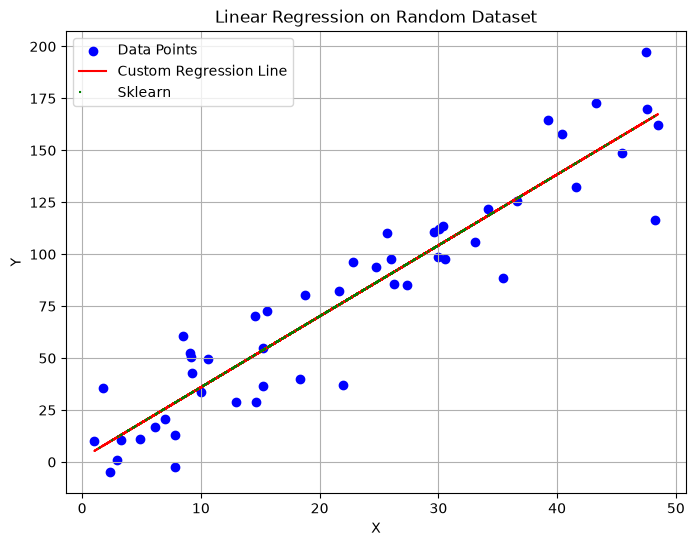

In [5]:
plt.figure(figsize=(8,6)) 
plt.scatter(X, Y, color='blue', label='Data Points') 
plt.plot(X, y_pred, color='red', label='Custom Regression Line') 
plt.plot(X, y_pred_sk, linestyle=(0,(1,15)), color='green', label='Sklearn') 
plt.title('Linear Regression on Random Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

### A noticeable caveat
LinearRegression doesn't require a manual step size. It's very likely that the function utilizes an adaptive stepsize through methods such as backtracking in order to prevent overstepping or slow convergence. Below is an example of how much the error can be with a bigger step size! 

In [6]:
model_overstep = fit(X,Y,stepsize=0.0015, metric="mse")
y_pred = predict(X,model[0],model[1])
print(f'Coefficients: {model_overstep[0]} \n Intercept: {model_overstep[1]} \n Error: {model_overstep[2]}')

Coefficients: [[nan]] 
 Intercept: -inf 
 Error: nan


c:\Users\vrost\algorithm portfolio\algorithm-portfolio\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
c:\Users\vrost\algorithm portfolio\algorithm-portfolio\Linear Regression From Fundamentals\metrics.py:10: RuntimeWarning: overflow encountered in square
  return np.mean((y - y_hat)**2)
c:\Users\vrost\algorithm portfolio\algorithm-portfolio\Linear Regression From Fundamentals\metrics.py:6: RuntimeWarning: overflow encountered in dot
  return -(2/n) * np.dot(X.T,(Y - theta_i))
c:\Users\vrost\algorithm portfolio\algorithm-portfolio\Linear Regression From Fundamentals\linear_regression.py:22: RuntimeWarning: invalid value encountered in subtract
  coeff = coeff - stepsize * D_c  # Update coeff


What happens here? When we use the gradient descent algorithm, it can overshoot the "valley" that the minimum function value is at. It will then attempt to self-correct, but only increase the magnitude of the error until it spirals out of control.

## Multidimensional Data Benchmark

In [7]:
np.random.seed(42)

X_4d = np.random.rand(50, 4) * 50  
coeff = np.array([[3.5],[-4.1],[0.5],[-3]])
Y_4d =  np.dot(X,coeff.T) + np.random.randn(50, 4) * 20

In [10]:
model = fit(X_4d,Y_4d,stepsize=0.00001, metric="mse")
model_sk = sk.linear_model.LinearRegression()
model_sk.fit(X_4d,Y_4d)
y_pred = predict(X_4d,model[0],model[1])
y_pred_sk = model_sk.predict(X_4d)
print(f'Coefficients: {model} \n Error: {model[2]}')
print(f'Sklearn error: {sk.metrics.mean_squared_error(Y_4d, y_pred_sk)}')


Coefficients: (array([[ 0.88014003, -0.95553344,  0.23619945, -0.47293764],
       [ 0.73549465, -0.3773387 ,  0.09019494, -0.44582942],
       [ 0.92557684, -0.99113839,  0.36755612, -0.61397275],
       [ 0.74856525, -0.81193002,  0.24806058, -0.57982281]]), np.float64(-9.722132992925145), np.float64(2955.754216822688)) 
 Error: 2955.754216822688
Sklearn error: 2579.6491451981437


### Another Method: QR Factorization
QR factorization splits our matrix $X$ into an upper triangular matrix, where $Q$ is orthogonal (its transpose is its inverse) and $R$ is upper triangular (all values below the diagonal are zero). This decomposition makes solving for linear regression easy to compute, as upper triangular matrices can be solved with an O(n) algorithm, and $Q$ gives us some convenient cancellation in the original problem.

In [37]:
Z = np.array([[12, -51, 4],
     [6, 167, -68],
     [-4, 24, -41]])
Q, R = householder(Z)
print(np.round(Q,3))
print(np.round(R,3))
print(np.dot(Q,R))

[[ 0.857 -0.394  0.331]
 [ 0.429  0.903 -0.034]
 [-0.286  0.171  0.943]]
[[ 14.  21. -14.]
 [  0. 175. -70.]
 [ -0.  -0. -35.]]
[[ 12. -51.   4.]
 [  6. 167. -68.]
 [ -4.  24. -41.]]


y-intercept: -22.866523341304042, slope: 4.198778029821136, error: 6364.428210004049
Numpy intercept: [1.93378549], Numpy slope: [3.4106264], Numpy error: 5085.963426783481


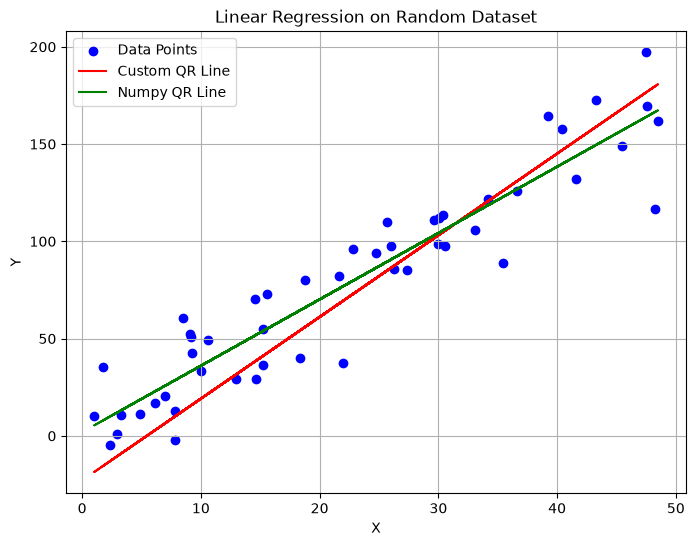

In [55]:
eq = np.hstack((X,np.ones((X.shape[0],1)))) #For QR factorization, X must also include a column of ones that represents the y-intercepts.
beta = qr_solve(eq,Y)
Q, R = np.linalg.qr(eq)
beta_np = np.linalg.solve(R, np.dot(Q.T,Y))
y_pred_qr = predict(X,beta[0],beta[1])
y_pred_np = predict(X, beta_np[0], beta_np[1])
error = MSE()
print(f"y-intercept: {beta[1]}, slope: {beta[0]}, error: {error.error(Y, y_pred_qr)}")
print(f"Numpy intercept: {beta_np[1]}, Numpy slope: {beta_np[0]}, Numpy error: {error.error(Y,y_pred_np)}")

plt.figure(figsize=(8,6)) 
plt.scatter(X, Y, color='blue', label='Data Points') 
plt.plot(X, y_pred_qr.T, color='red', label='Custom QR Line') 
plt.plot(X, y_pred_np.T, color='green', label='Numpy QR Line') 
plt.title('Linear Regression on Random Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

The error between the two is relatively close, though numpy's NP algorithm seems to pull ahead. The current custom QR function does not deal with scenarios where one of the vectors, $u$, is near zero, which can cause some numerical values to blow up over time.

## Future Use and Projects
I want to use these methods on a multidimensional dataframe for local apartment listings in Atascadero, where I've been househunting for the last couple of months. Variables include square footage, utilities included in rent, pet policy, walkability score, and number of beds/baths. All of these will be used to approximate the cost of rent.

### Requirements
- Splitting data into training and test info.
- Collection and cleaning of data from a reliable website (e.g. Zillow, Realtor, Apartments.com). This includes OneHot encoding binary variables, systematically cleaning missing info, and so on.
- Ensuring all variables are not collinear. As to say, no two items are highly correlated with one another.
- Adding an LLM to answer questions based on given information and scoring.